In [5]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import pandas as pd

In [33]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [41]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [47]:
model = LogisticRegression()
model.fit(X, y)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [49]:
y_pred = model.predict(X)

In [91]:
def plot_feature_vs_target(feature1, feature2, target, title):
    plt.title(title)
    plt.scatter(feature1, feature2, c=target)

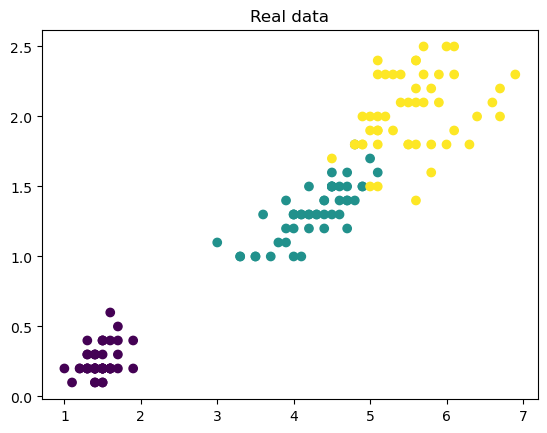

In [93]:
plot_feature_vs_target(X['petal length (cm)'], X['petal width (cm)'], y, 'Real data')

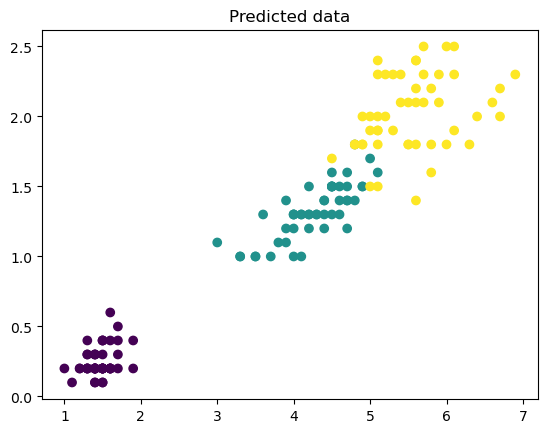

In [97]:
plot_feature_vs_target(X['petal length (cm)'], X['petal width (cm)'], y, 'Predicted data')

In [99]:
model.score(X, y)

0.9733333333333334

<Axes: >

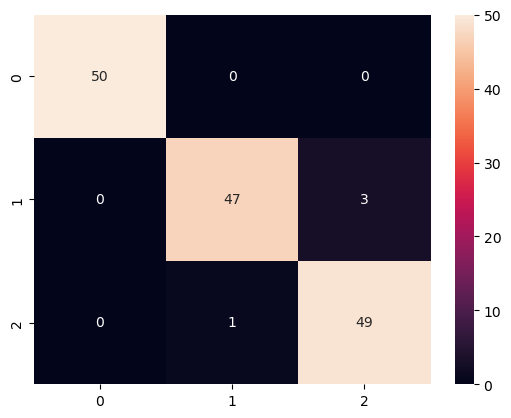

In [101]:
import seaborn
from sklearn.metrics import confusion_matrix

seaborn.heatmap(confusion_matrix(y, y_pred), annot = True)

In [105]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

# Thiết lập tham số cho bộ dữ liệu
n_samples = 200  # Số lượng mẫu
n_features = 4   # Số lượng biến độc lập
n_informative = 3  # Số biến độc lập quan trọng (liên quan đến mục tiêu)
n_redundant = 1  # Số biến dư thừa (kết hợp tuyến tính từ các biến khác)
random_state = 42  # Seed để tái lập

# Tạo bộ dữ liệu phân loại
X, y = make_classification(
    n_samples=n_samples, 
    n_features=n_features, 
    n_informative=n_informative, 
    n_redundant=n_redundant, 
    n_classes=2,  # Phân loại nhị phân (0 và 1)
    random_state=random_state
)

# Tổ chức dữ liệu thành DataFrame
feature_names = [f'Feature_{i+1}' for i in range(n_features)]
data = pd.DataFrame(X, columns=feature_names)
data['Target'] = y

In [107]:
data.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,1.906484,-1.799831,-0.965512,-1.831212,0
1,-0.101875,2.493410,2.061121,0.129556,1
2,1.982068,2.642358,0.250049,-1.333129,1
3,1.958343,2.455314,-1.652526,-0.961838,1
4,0.126036,0.748488,-0.093466,0.043284,1


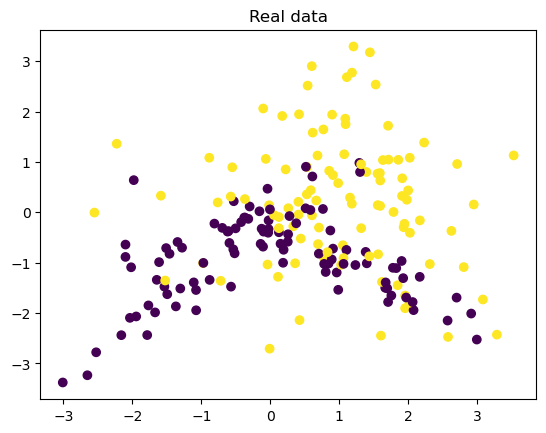

In [183]:
plot_feature_vs_target(data['Feature_1'], data['Feature_3'], data['Target'], 'Real data')

In [127]:
data.corr()

,Feature_1,Feature_2,Feature_3,Feature_4,Target
Feature_1,1.000000,0.058744,0.165791,-0.979902,0.363527
Feature_2,0.058744,1.000000,0.513170,0.045807,0.664352
Feature_3,0.165791,0.513170,1.000000,-0.254728,0.462828
Feature_4,-0.979902,0.045807,-0.254728,1.000000,-0.305163
Target,0.363527,0.664352,0.462828,-0.305163,1.000000


In [129]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV

In [143]:
feature_names = data.columns[:-1]

In [167]:
model = LogisticRegression()
cv = KFold(n_splits=10, shuffle=True, random_state=1234)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Các giá trị của tham số regularization
    'penalty': ['l2'],  # L2 regularization (L1 cần solver=saga hoặc liblinear)
    'solver': ['lbfgs', 'liblinear']  # Các thuật toán tối ưu
}

# Khởi tạo GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                           cv=cv, scoring='accuracy', verbose=1)

grid_search.fit(data[feature_names], data['Target'])

Fitting 10 folds for each of 10 candidates, totalling 100 fits


GridSearchCV(cv=KFold(n_splits=10, random_state=1234, shuffle=True),
             estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy', verbose=1)

In [169]:
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [199]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,param_solver,params,split0_test_score,split1_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002395,0.002696,0.000242,0.000399,0.01,l2,lbfgs,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.95,1.0,...,0.85,0.9,0.95,0.95,0.85,0.85,0.80,0.900,0.059161,9
1,0.000200,0.000401,0.000113,0.000338,0.01,l2,liblinear,"{'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...",0.95,1.0,...,0.85,0.9,0.95,0.95,0.85,0.85,0.80,0.895,0.061033,10
2,0.004061,0.005777,0.000922,0.001086,0.1,l2,lbfgs,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.95,1.0,...,0.85,0.9,0.95,0.95,0.85,0.85,0.85,0.905,0.052202,7
3,0.001972,0.004623,0.002022,0.004591,0.1,l2,liblinear,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.95,1.0,...,0.85,0.9,0.95,0.95,0.85,0.85,0.85,0.905,0.052202,7
4,0.002518,0.005212,0.000659,0.001976,1,l2,lbfgs,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.95,1.0,...,0.90,0.9,1.00,0.95,0.85,0.85,0.90,0.920,0.050990,1
5,0.000000,0.000000,0.003134,0.006268,1,l2,liblinear,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.95,1.0,...,0.90,0.9,1.00,0.95,0.85,0.85,0.90,0.920,0.050990,1
6,0.003236,0.004534,0.002216,0.004514,10,l2,lbfgs,"{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}",0.95,1.0,...,0.90,0.9,1.00,0.95,0.85,0.85,0.90,0.920,0.050990,1
7,0.000358,0.000798,0.000123,0.000368,10,l2,liblinear,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}",0.95,1.0,...,0.90,0.9,1.00,0.95,0.85,0.85,0.90,0.920,0.050990,1
8,0.002872,0.005772,0.000000,0.000000,100,l2,lbfgs,"{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}",0.95,1.0,...,0.90,0.9,1.00,0.95,0.85,0.85,0.90,0.920,0.050990,1
9,0.001571,0.004713,0.000000,0.000000,100,l2,liblinear,"{'C': 100, 'penalty': 'l2', 'solver': 'libline...",0.95,1.0,...,0.90,0.9,1.00,0.95,0.85,0.85,0.90,0.920,0.050990,1


In [201]:
print(grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_)

LogisticRegression(C=1) {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'} 0.9199999999999999


In [179]:
y_pred = grid_search.predict(data[feature_names])
y_pred

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0])

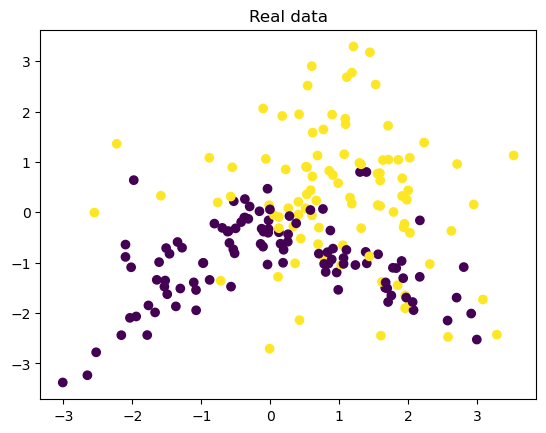

In [181]:
plot_feature_vs_target(data['Feature_1'], data['Feature_3'], y_pred, 'Real data')

In [193]:
from sklearn.metrics import accuracy_score

accuracy_score(data['Target'], y_pred)

0.93

<Axes: >

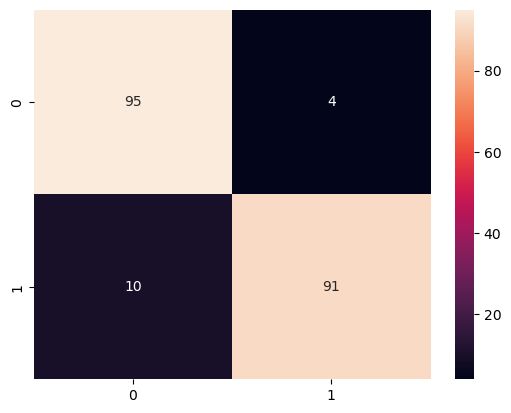

In [195]:
seaborn.heatmap(confusion_matrix(data['Target'], y_pred), annot = True)